# 1. Imports & global config

In [2]:
#  Level 3 – GRU Sentiment Analysis

import os
import re
from collections import Counter
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint

from IPython.display import display

print("TensorFlow:", tf.__version__)
nltk.download("stopwords")

TensorFlow: 2.18.1


[nltk_data] Downloading package stopwords to /home/rabby/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 2. Hyperparameters & Paths

In [5]:
# Model Hyperparameters
EMBEDDING_DIM = 300
BATCH_SIZE = 10000
EPOCHS = 10
LR = 1e-3

# Tokenizer / Sequence Hyperparameters
MAX_WORDS = 100000
MAX_SEQ_LENGTH = 30

# Paths
DATA_PATH = "data/training.1600000.processed.noemoticon.csv"
GLOVE_PATH = "data/glove.6B.300d.txt"

MODEL_PATH_GRU_BEST = "saved_models/gru_best.h5"
MODEL_PATH_GRU_FINAL = "saved_models/gru_final_model.h5"

os.makedirs("saved_models", exist_ok=True)

# 3. Load Dataset

In [8]:
# Load Sentiment140 Dataset
df = pd.read_csv(
    DATA_PATH,
    header=None,
    engine="python",
    encoding="latin-1",
    encoding_errors="ignore"
)

df.columns = ["sentiment", "id", "date", "query", "user_id", "text"]
df = df[["sentiment", "text"]]

print(df.shape)
display(df.head())

(1600000, 2)


,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


# 4. EDA (Exploratory Data Analysis)

## Sentiment Distribution

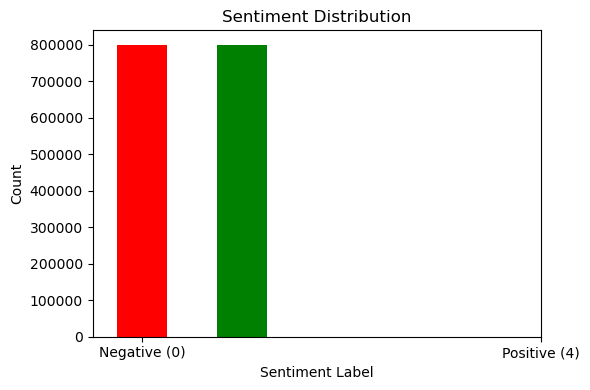

In [12]:
# Sentiment Distribution with Vertical Labels
plt.figure(figsize=(6, 4))
df["sentiment"].value_counts().sort_index().plot(kind="bar", color=["red", "green"])
plt.xticks([0, 4], ["Negative (0)", "Positive (4)"], rotation=0)  # Added rotation=0
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## weet Length (Histogram + Boxplot)

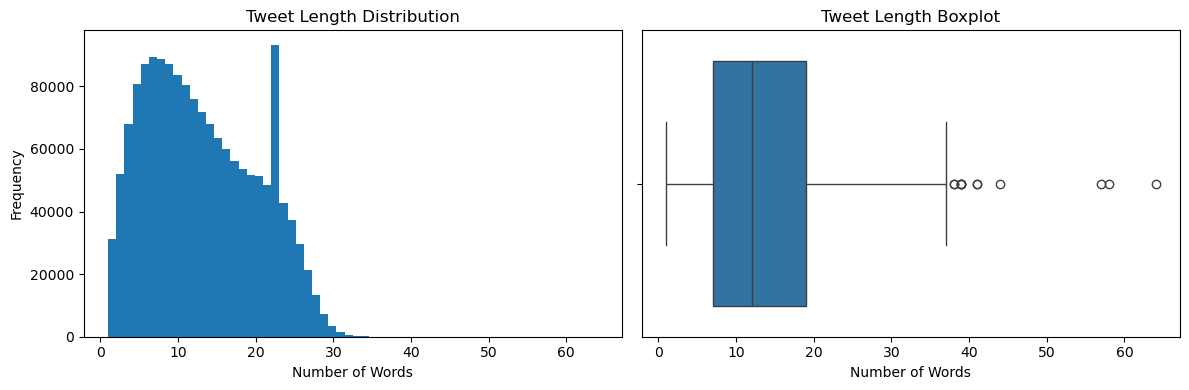

In [15]:
#   3. EDA – Tweet Length

df["text_len"] = df["text"].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df["text_len"], bins=60)
axes[0].set_title("Tweet Length Distribution")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Frequency")

# Boxplot
sns.boxplot(x=df["text_len"], ax=axes[1])
axes[1].set_title("Tweet Length Boxplot")
axes[1].set_xlabel("Number of Words")

plt.tight_layout()
plt.show()

## WordClouds

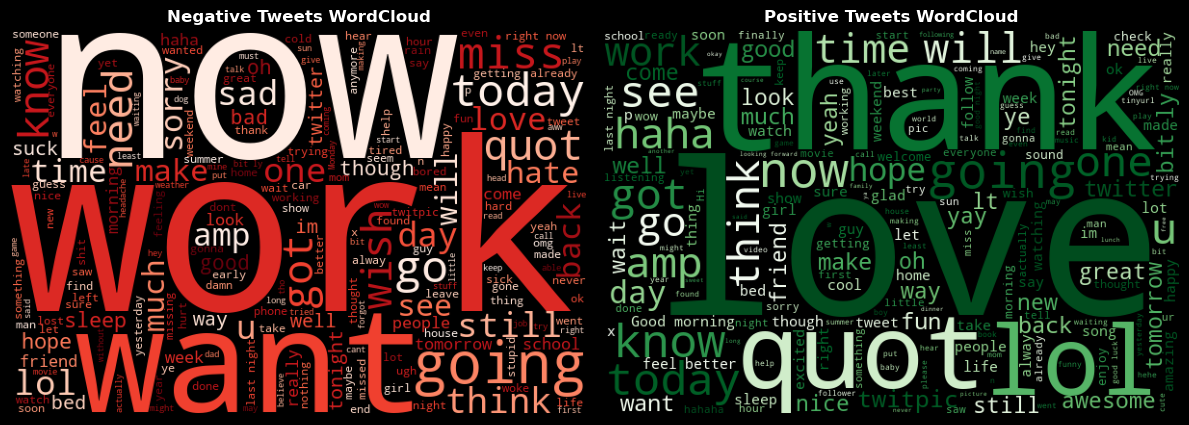

In [35]:
neg_text = " ".join(df[df["sentiment"] == 0]["text"].astype(str).tolist())
pos_text = " ".join(df[df["sentiment"] == 4]["text"].astype(str).tolist())

plt.figure(figsize=(12, 5))

# Negative - Red colors on black
plt.subplot(1, 2, 1)
wc_neg = WordCloud(width=600, height=400, 
                   background_color="black",
                   colormap="Reds").generate(neg_text)
plt.imshow(wc_neg)
plt.title("Negative Tweets WordCloud", color='white', fontweight='bold')
plt.axis("off")

# Positive - Green colors on black
plt.subplot(1, 2, 2)
wc_pos = WordCloud(width=600, height=400, 
                   background_color="black",
                   colormap="Greens").generate(pos_text)
plt.imshow(wc_pos)
plt.title("Positive Tweets WordCloud", color='white', fontweight='bold')
plt.axis("off")

# Set figure background to black
plt.gcf().set_facecolor('black')
plt.tight_layout()
plt.show()

## Top 20 Words per Class

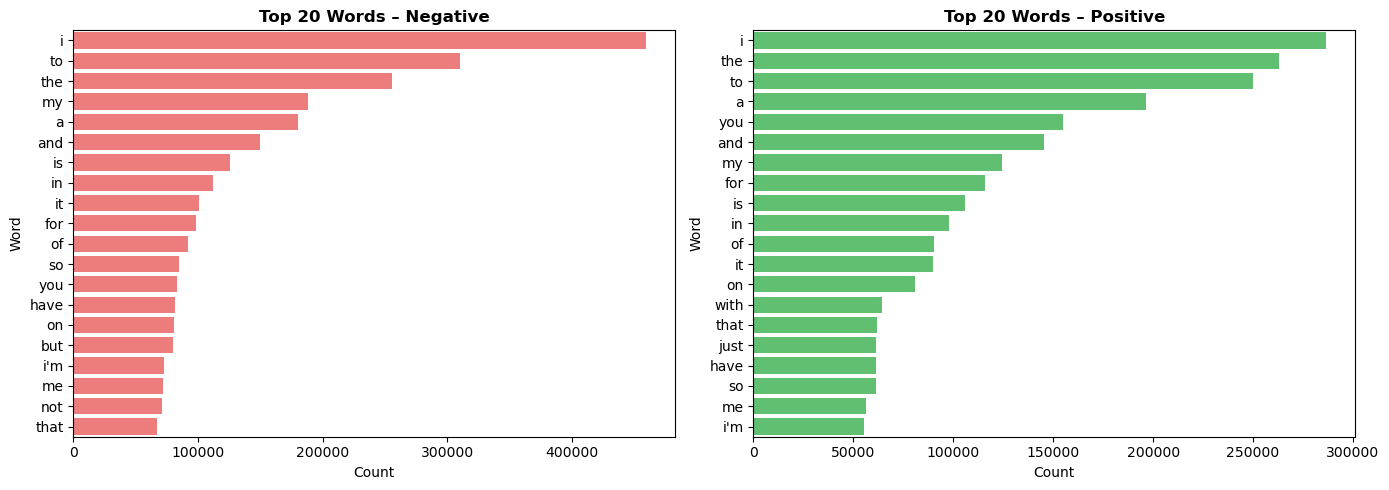

In [33]:
def top_n_words(texts, n=20):
    all_words = " ".join(texts).lower().split()
    counter = Counter(all_words)
    return counter.most_common(n)

top_neg = top_n_words(df[df["sentiment"] == 0]["text"].astype(str), n=20)
top_pos = top_n_words(df[df["sentiment"] == 4]["text"].astype(str), n=20)

neg_words, neg_counts = zip(*top_neg)
pos_words, pos_counts = zip(*top_pos)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Negative words in red tones
sns.barplot(x=list(neg_counts), y=list(neg_words), ax=axes[0], color='#ff6b6b')
axes[0].set_title("Top 20 Words – Negative", fontweight='bold')
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Word")

# Positive words in green tones
sns.barplot(x=list(pos_counts), y=list(pos_words), ax=axes[1], color='#51cf66')
axes[1].set_title("Top 20 Words – Positive", fontweight='bold')
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Word")

plt.tight_layout()
plt.show()

# 5. Text Preprocessing

In [41]:
stop_words = stopwords.words("english")
stemmer = SnowballStemmer("english")

clean_re = r'@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+'  # remove mentions, URLs, non-alphanum

def preprocess(text, stem=False):
    text = re.sub(clean_re, " ", str(text).lower()).strip()
    tokens = []
    for token in text.split():
        if token not in stop_words:
            tokens.append(stemmer.stem(token) if stem else token)
    return " ".join(tokens)

# 7. Apply Cleaning

In [44]:
df["clean_text"] = df["text"].apply(preprocess)
display(df[["text", "clean_text"]].head())

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,upset update facebook texting might cry result...
2,@Kenichan I dived many times for the ball. Man...,dived many times ball managed save 50 rest go ...
3,my whole body feels itchy and like its on fire,whole body feels itchy like fire
4,"@nationwideclass no, it's not behaving at all....",behaving mad see


# 8. Train/Test Split

In [48]:
train_df, test_df = train_test_split(
    df[["sentiment", "clean_text"]],
    test_size=0.2,
    random_state=666,
    shuffle=True
)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (1280000, 2)
Test size: (320000, 2)


# 9. Tokenizer & Padding

In [52]:
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(train_df["clean_text"])

x_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df["clean_text"]),
    maxlen=MAX_SEQ_LENGTH
)

x_test = pad_sequences(
    tokenizer.texts_to_sequences(test_df["clean_text"]),
    maxlen=MAX_SEQ_LENGTH
)

y_train = (train_df["sentiment"] == 4).astype(int).values
y_test = (test_df["sentiment"] == 4).astype(int).values

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (1280000, 30)
x_test shape: (320000, 30)
y_train shape: (1280000,)
y_test shape: (320000,)


# 9. Load GloVe Embeddings

In [57]:
embedding_index = {}

with open(GLOVE_PATH, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

print("Loaded word vectors:", len(embedding_index))

Loaded word vectors: 400000


# 10. Build Embedding Matrix

In [60]:
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

for word, idx in tokenizer.word_index.items():
    if idx < vocab_size:
        vec = embedding_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (290683, 300)


# 11. Build GRU Model

In [64]:
gru_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_shape=(MAX_SEQ_LENGTH,),
        trainable=False
    ),
    GRU(128),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

gru_model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    metrics=["accuracy"]
)

gru_model.summary()

/home/rabby/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 300)        │    87,204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │       165,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,370,149 (333.29 MB)

 Trainable params: 165,249 (645.50 KB)

 Non-trainable params: 87,204,900 (332.66 MB)

# 12. Train GRU Model

In [71]:
start_time = time.time()

history_gru = gru_model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
)

end_time = time.time()
training_time_gru = end_time - start_time

print(f"GRU Training time: {training_time_gru:.2f} seconds")

Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.7143 - loss: 0.5514 - val_accuracy: 0.7478 - val_loss: 0.5106
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.7531 - loss: 0.5014 - val_accuracy: 0.7622 - val_loss: 0.4882
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.7638 - loss: 0.4859 - val_accuracy: 0.7687 - val_loss: 0.4786
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.7694 - loss: 0.4769 - val_accuracy: 0.7719 - val_loss: 0.4729
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.7737 - loss: 0.4705 - val_accuracy: 0.7737 - val_loss: 0.4705
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.7765 - loss: 0.4662 - val_accuracy: 0.7767 - val_loss: 0.4652
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.7795 - loss: 0.4620 - val_accuracy: 0.7785 - val_loss: 0.4630
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.7812 - loss: 0.4585 - val_accu

# 13. Visualization

# 13.1 GRU Loss Curves

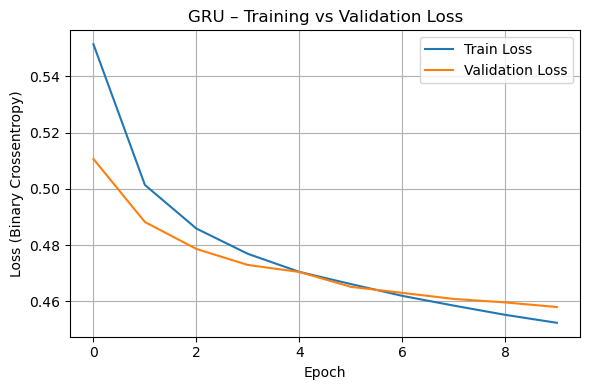

In [79]:
plt.figure(figsize=(6, 4))
plt.plot(history_gru.history["loss"], label="Train Loss")
plt.plot(history_gru.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Crossentropy)")
plt.title("GRU – Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 13.2 GRU Accuracy Curves

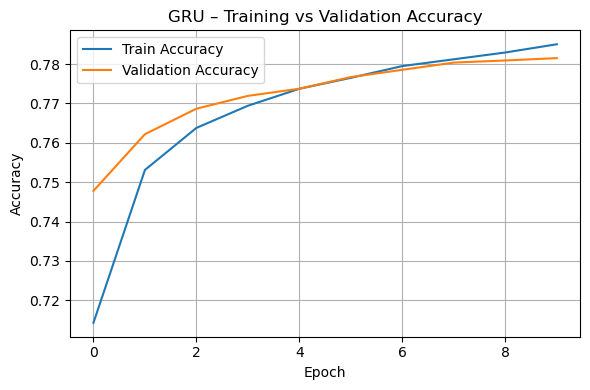

In [82]:
plt.figure(figsize=(6, 4))
plt.plot(history_gru.history["accuracy"], label="Train Accuracy")
plt.plot(history_gru.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU – Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 13.3 GRU Test Evaluation

In [85]:
test_loss_gru, test_acc_gru = gru_model.evaluate(
    x_test, y_test,
    batch_size=BATCH_SIZE
)

print(f"GRU – Test Loss:     {test_loss_gru:.4f}")
print(f"GRU – Test Accuracy: {test_acc_gru:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 845ms/step - accuracy: 0.7811 - loss: 0.4583
GRU – Test Loss:     0.4583
GRU – Test Accuracy: 0.7811


# 13.4 GRU Confusion Matrix + F1

32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 834ms/step


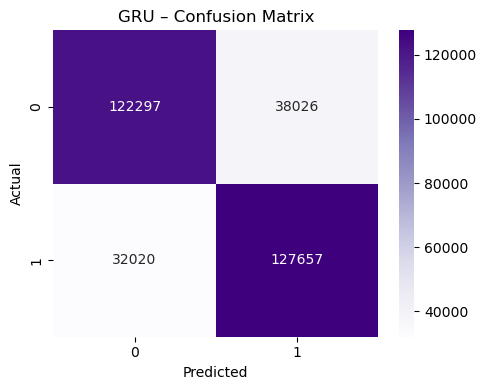


GRU – Classification Report:

              precision    recall  f1-score   support

    Negative       0.79      0.76      0.78    160323
    Positive       0.77      0.80      0.78    159677

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000

GRU – F1-score: 0.7847


In [89]:
y_prob_gru = gru_model.predict(x_test, batch_size=BATCH_SIZE)
y_pred_gru = (y_prob_gru >= 0.5).astype("int32").ravel()

cm_gru = confusion_matrix(y_test, y_pred_gru)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_gru, annot=True, fmt="d", cmap="Purples")
plt.title("GRU – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

f1_gru = f1_score(y_test, y_pred_gru)
print("\nGRU – Classification Report:\n")
print(classification_report(y_test, y_pred_gru, target_names=["Negative","Positive"]))
print(f"GRU – F1-score: {f1_gru:.4f}")

# 13.5 GRU Prediction Probability Distribution

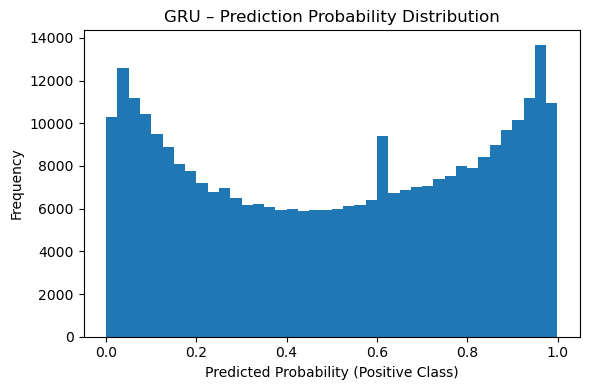

In [93]:
plt.figure(figsize=(6, 4))
plt.hist(y_prob_gru, bins=40)
plt.xlabel("Predicted Probability (Positive Class)")
plt.ylabel("Frequency")
plt.title("GRU – Prediction Probability Distribution")
plt.tight_layout()
plt.show()

# 14. Save GRU Model & Tokenizer

In [103]:
gru_model.save(MODEL_PATH_GRU_FINAL)

import pickle
with open("saved_models/tokenizer_gru.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print(f"Saved best GRU model to:   {MODEL_PATH_GRU_BEST}")
print(f"Saved final GRU model to:  {MODEL_PATH_GRU_FINAL}")
print("Saved GRU tokenizer to:    saved_models/tokenizer_gru.pkl")

Saved best GRU model to:   saved_models/gru_best.h5
Saved final GRU model to:  saved_models/gru_final_model.h5
Saved GRU tokenizer to:    saved_models/tokenizer_gru.pkl


# 15. Load RNN & LSTM Models (from Level 1 & 2)

In [106]:
RNN_MODEL_PATH = "saved_models/rnn_final_model.h5"
LSTM_MODEL_PATH = "saved_models/lstm_final_model.h5"

RNN_TOKENIZER_PATH = "saved_models/tokenizer.pkl"
LSTM_TOKENIZER_PATH = "saved_models/tokenizer_lstm.pkl"

rnn_model = tf.keras.models.load_model(RNN_MODEL_PATH)
lstm_model = tf.keras.models.load_model(LSTM_MODEL_PATH)

import pickle
with open(RNN_TOKENIZER_PATH, "rb") as f:
    rnn_tokenizer = pickle.load(f)

with open(LSTM_TOKENIZER_PATH, "rb") as f:
    lstm_tokenizer = pickle.load(f)

print("Loaded RNN & LSTM models and tokenizers.")


Loaded RNN & LSTM models and tokenizers.


## 15.1 Evaluate RNN on Level 3 Test Set

In [109]:
x_test_rnn = pad_sequences(
    rnn_tokenizer.texts_to_sequences(test_df["clean_text"]),
    maxlen=MAX_SEQ_LENGTH
)

test_loss_rnn, test_acc_rnn = rnn_model.evaluate(
    x_test_rnn, y_test,
    batch_size=BATCH_SIZE
)

y_prob_rnn = rnn_model.predict(x_test_rnn, batch_size=BATCH_SIZE)
y_pred_rnn = (y_prob_rnn >= 0.5).astype("int32").ravel()
f1_rnn = f1_score(y_test, y_pred_rnn)

print(f"RNN – Test Loss:     {test_loss_rnn:.4f}")
print(f"RNN – Test Accuracy: {test_acc_rnn:.4f}")
print(f"RNN – F1-score:      {f1_rnn:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 369ms/step - accuracy: 0.7573 - loss: 0.4959
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 335ms/step
RNN – Test Loss:     0.4959
RNN – Test Accuracy: 0.7573
RNN – F1-score:      0.7620


## 15.2 Evaluate LSTM on Level 3 Test Set

In [112]:
x_test_lstm = pad_sequences(
    lstm_tokenizer.texts_to_sequences(test_df["clean_text"]),
    maxlen=MAX_SEQ_LENGTH
)

test_loss_lstm, test_acc_lstm = lstm_model.evaluate(
    x_test_lstm, y_test,
    batch_size=BATCH_SIZE
)

y_prob_lstm = lstm_model.predict(x_test_lstm, batch_size=BATCH_SIZE)
y_pred_lstm = (y_prob_lstm >= 0.5).astype("int32").ravel()
f1_lstm = f1_score(y_test, y_pred_lstm)

print(f"LSTM – Test Loss:     {test_loss_lstm:.4f}")
print(f"LSTM – Test Accuracy: {test_acc_lstm:.4f}")
print(f"LSTM – F1-score:      {f1_lstm:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 930ms/step - accuracy: 0.7819 - loss: 0.4573
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 902ms/step
LSTM – Test Loss:     0.4573
LSTM – Test Accuracy: 0.7819
LSTM – F1-score:      0.7899


# 16. RNN vs LSTM vs GRU – Metric Comparison

,Model,Accuracy,F1-score
0,RNN,0.757306,0.762042
1,LSTM,0.781944,0.789937
2,GRU,0.781106,0.784712


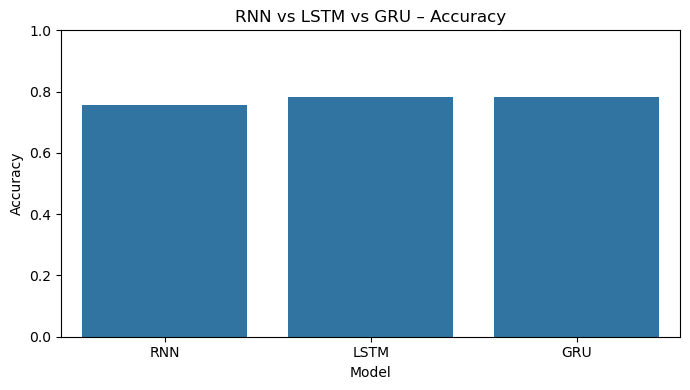

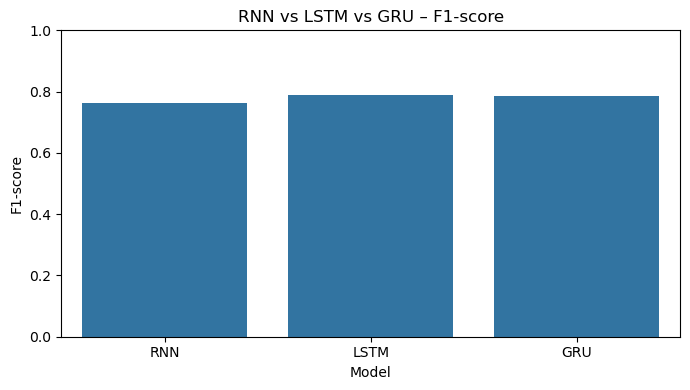

In [115]:
results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Accuracy": [test_acc_rnn, test_acc_lstm, test_acc_gru],
    "F1-score": [f1_rnn, f1_lstm, f1_gru]
})

display(results)

plt.figure(figsize=(7, 4))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.ylim(0, 1)
plt.title("RNN vs LSTM vs GRU – Accuracy")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(x="Model", y="F1-score", data=results)
plt.ylim(0, 1)
plt.title("RNN vs LSTM vs GRU – F1-score")
plt.tight_layout()
plt.show()

## Model Complexity Comparison

,Model,Parameters
0,RNN,87259941
1,LSTM,87424677
2,GRU,87370149


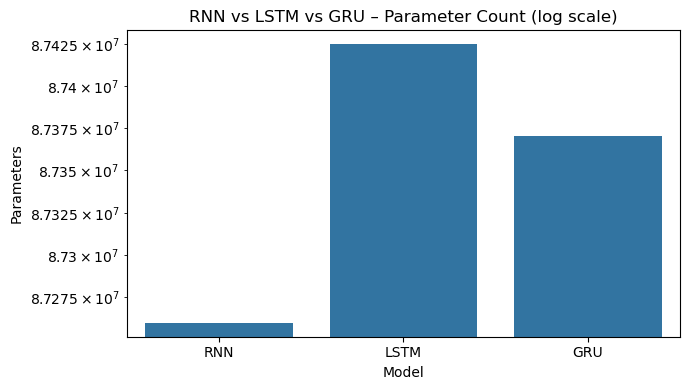

In [118]:
params_rnn = rnn_model.count_params()
params_lstm = lstm_model.count_params()
params_gru = gru_model.count_params()

comp_df = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Parameters": [params_rnn, params_lstm, params_gru]
})

display(comp_df)

plt.figure(figsize=(7, 4))
sns.barplot(x="Model", y="Parameters", data=comp_df)
plt.yscale("log")
plt.title("RNN vs LSTM vs GRU – Parameter Count (log scale)")
plt.tight_layout()
plt.show()

# 17. Real-Time Prediction Using GRU

In [123]:
gru_loaded = tf.keras.models.load_model(MODEL_PATH_GRU_BEST)

with open("saved_models/tokenizer_gru.pkl", "rb") as f:
    tokenizer_loaded_gru = pickle.load(f)

def predict_sentiment_gru(text: str):
    cleaned = preprocess(text)
    seq = tokenizer_loaded_gru.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_SEQ_LENGTH)
    prob = gru_loaded.predict(pad)[0][0]
    label = "Positive" if prob >= 0.5 else "Negative"
    return label, float(prob)

# Demo
print(predict_sentiment_gru("I absolutely love this, it is fantastic!"))
print(predict_sentiment_gru("This is really bad, I hate it."))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
('Positive', 0.9918339252471924)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
('Negative', 0.021742060780525208)
